In [1]:
import brian2
from brian2 import mV, ms, nS, nF
import matplotlib.pyplot as plt

WARNING    neurongroup_1's variable 'v' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]
WARNING    /home/yi/.local/lib/python3.6/site-packages/brian2/units/fundamentalunits.py:1397: RuntimeWarning: overflow encountered in true_divide
  result = operation(self_arr, other_arr)
 [py.warnings]


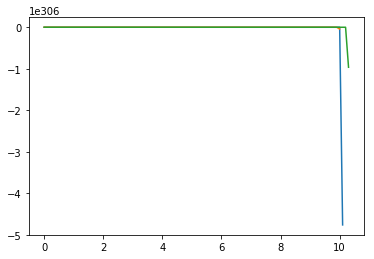

In [6]:
brian2.start_scope()
eqs_PCs = """
dv/dt = (-g_m*(v-v_rest) + I_syn)/C_m : volt
I_syn = I_AMPA_ext + I_AMPA_rec + I_NMDA_rec + I_GABA_rec : ampere
I_AMPA_ext = g_AMPA_ext*(v-V_E) : ampere
I_AMPA_rec = 1*nS*(v-V_E) : ampere
I_NMDA_rec = 0*mA : ampere
I_GABA_rec = 0*mA : ampere
g_AMPA_ext : siemens
noise : siemens
"""

G = brian2.NeuronGroup(
    3, eqs_PCs, threshold='v>-52*mV', reset='v=-59*mV',
    namespace={
        'g_m':25*nS,
        'C_m':0.5*nF,
        'v_rest':-70*mV,
        'V_E':1*mV,
#        'V_I':'-70*mV',
    },
    method='euler'
)

eqs_AMPA_ext = """
g_AMPA_ext_post = scl*(g_r + g_d)/norm : siemens (summed)
dg_r/dt = -g_r/tau_r + noise_pre/(1000*ms) : siemens (clock-driven)
dg_d/dt = -g_d/tau_d + noise_pre/(1000*ms) : siemens (clock-driven)
scl = 1 : 1
norm = 0.472689 : 1
w = 0.0825*nS : siemens
tau_r = 0.5*ms : second
tau_d = 20*ms : second
"""
eqs_AMPA_ext_onpre = """
g_r += w
g_d += w
"""
C_AMPA_ext = brian2.Synapses(
    G, G, model=eqs_AMPA_ext, on_pre=eqs_AMPA_ext_onpre,
    method='euler'
)
C_AMPA_ext.connect('i!=j')

P = brian2.PoissonInput(G, 'noise', 100, 100*brian2.Hz, '16000*uS')
M = brian2.StateMonitor(G, 'v', record=list(range(G._N)))
brian2.run(50*ms)
for n in range(G._N):
    plt.plot(M.t/ms, M.v[n]/brian2.mV)

In [7]:
1/(0.5*brian2.nF)*brian2.nF

1.9999999999999998